## Lecture 7: Off-lattice Monte Carlo simulations

The main code was written in C++ and is available in the ```code/``` folder. Single executables can be compiled and linked with Cmake.
This Python notebook serves as an offline data elaboration.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
import os 
plt.style.use('science')

First of all, let's plot the radial distribution function $g(r)$ for various densities:

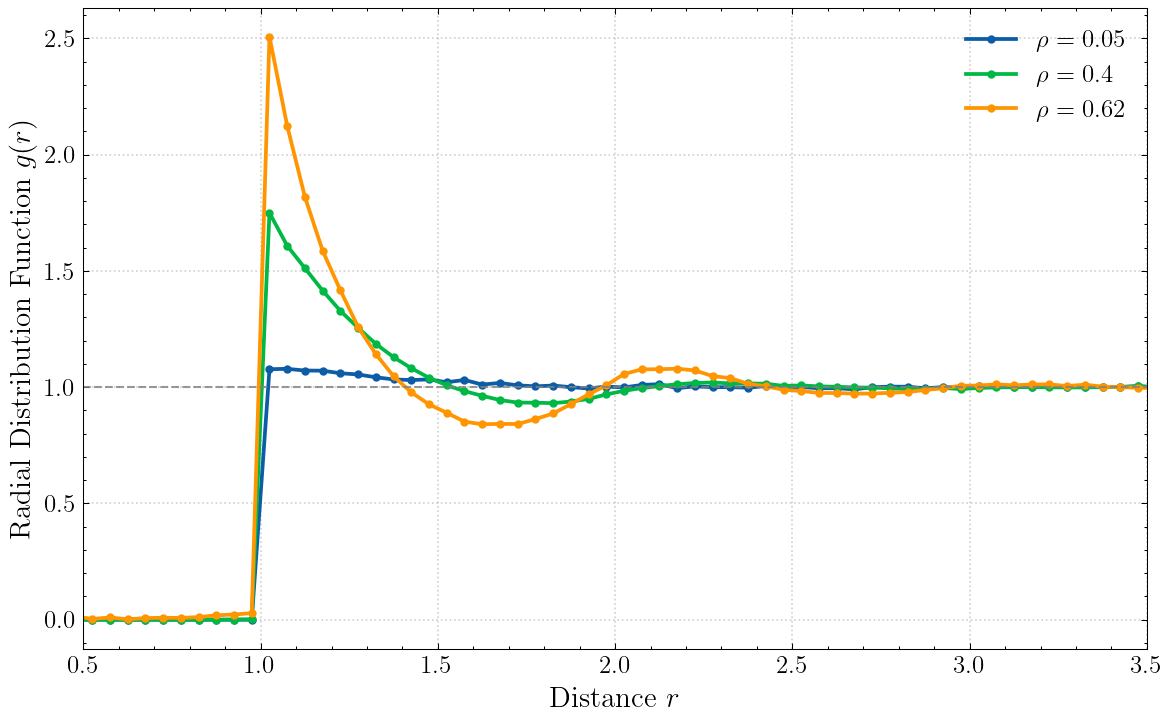

In [ ]:
file_base_liquid = './data/RDF_liquid/data'
file_base_gas = './data/RDF_gas/data'
file_base_solid = './data/RDF_solid/data'

rdf_liquid = np.zeros((200, 2))
rdf_gas = np.zeros((200, 2))
rdf_solid = np.zeros((200, 2))

for i in range(4500):
    data = np.loadtxt( f"{file_base_liquid}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_liquid[:,0] = r
    rdf_liquid[:,1] += g_r/4500.0

    data = np.loadtxt( f"{file_base_gas}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_gas[:,0] = r
    rdf_gas[:,1] += g_r/4500.0

    data = np.loadtxt( f"{file_base_solid}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_solid[:,0] = r
    rdf_solid[:,1] += g_r/4500.0

plt.figure(figsize=(8, 5), dpi=150)
plt.plot(rdf_gas[:,0], rdf_gas[:,1], marker = "o",markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.05$")
plt.plot(rdf_liquid[:,0], rdf_liquid[:,1], marker = "o", markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.4$")
plt.plot(rdf_solid[:,0], rdf_solid[:,1], marker = "o",markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.62$")
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.8)
plt.xlim(0.5, 3.5)
plt.xlabel(r"Distance $r$", fontsize=14)
plt.ylabel(r"Radial Distribution Function $g(r)$", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=12)
plt.tight_layout()
#plt.savefig('./fig/RDF_plot.pdf', dpi=300)
plt.show()


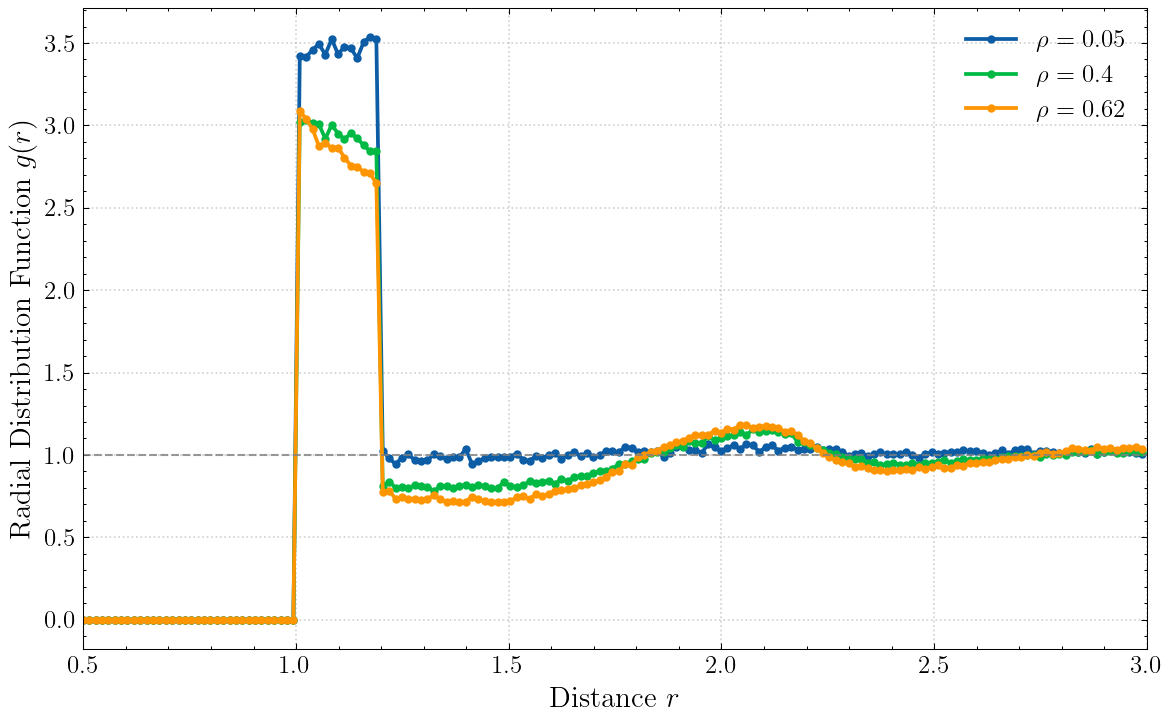

In [ ]:
file_base_liquid = './data/RDF_liquid_well/data'
file_base_gas = './data/RDF_gas_well/data'
file_base_solid = './data/RDF_solid_well/data'

rdf_liquid = np.zeros((400, 2))
rdf_gas = np.zeros((400, 2))
rdf_solid = np.zeros((400, 2))

for i in range(4500):
    data = np.loadtxt( f"{file_base_liquid}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_liquid[:,0] = r
    rdf_liquid[:,1] += g_r/4500.0

    data = np.loadtxt( f"{file_base_gas}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_gas[:,0] = r
    rdf_gas[:,1] += g_r/4500.0

    data = np.loadtxt( f"{file_base_solid}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_solid[:,0] = r
    rdf_solid[:,1] += g_r/4500.0



plt.figure(figsize=(8, 5), dpi=150)
plt.plot(rdf_gas[:,0][::2], rdf_gas[:,1][::2], marker = "o",markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.05$")
plt.plot(rdf_liquid[:,0][::2], rdf_liquid[:,1][::2], marker = "o", markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.4$")
plt.plot(rdf_solid[:,0][::2], rdf_solid[:,1][::2], marker = "o",markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.62$")
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.8)
plt.xlim(0.5, 3)
plt.xlabel(r"Distance $r$", fontsize=14)
plt.ylabel(r"Radial Distribution Function $g(r)$", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=12)
plt.tight_layout()
plt.savefig('./fig/RDF_plot_well.pdf', dpi=300)
plt.show()

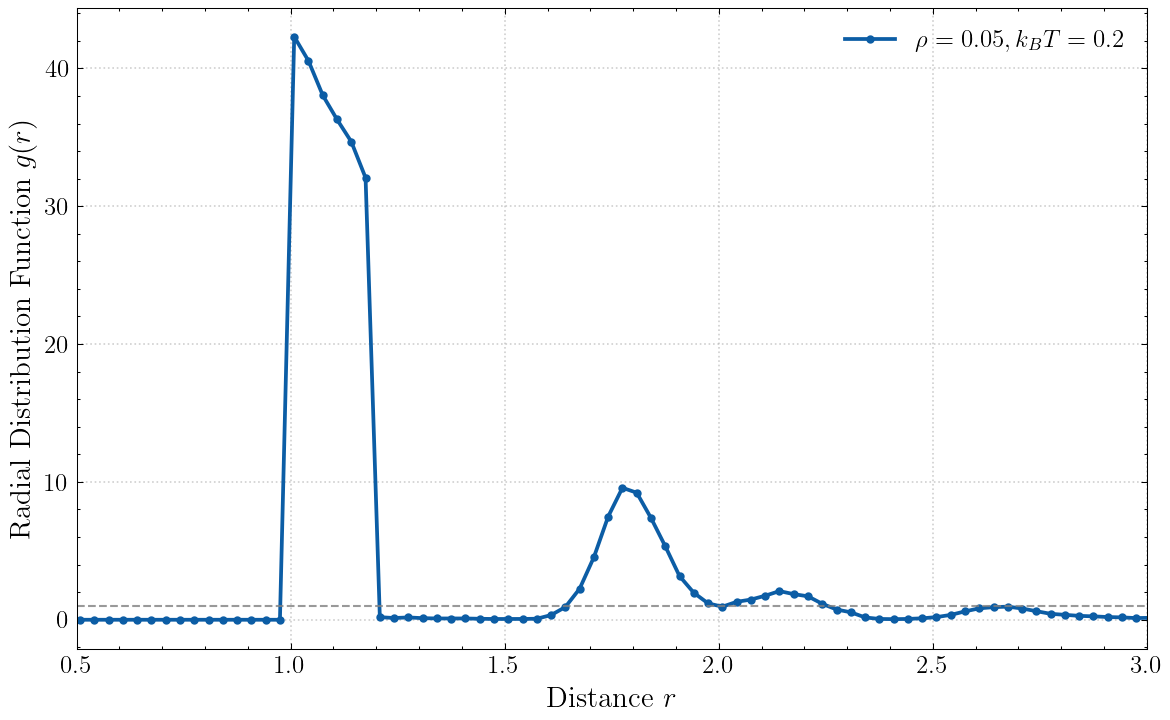

In [29]:
file_base_gas_condensed = './data/RDF_gas_well_condensed/data'
rdf_gas_condensed = np.zeros((300, 2))

for i in np.arange(75000, 100000, 5):
    data = np.loadtxt( f"{file_base_gas_condensed}.{i}",comments='#', delimiter=None, skiprows=1)
    r = data[:, 0] 
    g_r = data[:, 1]
    rdf_gas_condensed[:,0] = r
    rdf_gas_condensed[:,1] += g_r/5000.0


plt.figure(figsize=(8, 5), dpi=150)
plt.plot(rdf_gas_condensed[:,0][::2], rdf_gas_condensed[:,1][::2], marker = "o",markersize=3, linestyle='-', linewidth=1.8, label=r"$\rho = 0.05, k_B T = 0.2$")
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.8)
plt.xlim(0.5, 3)
plt.xlabel(r"Distance $r$", fontsize=14)
plt.ylabel(r"Radial Distribution Function $g(r)$", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
plt.legend(framealpha=0.9, fontsize=12)
plt.tight_layout()
plt.savefig('./fig/RDF_plot_well_gas_condensed.pdf', dpi=300)
plt.show()

Now, up for the energy analysis

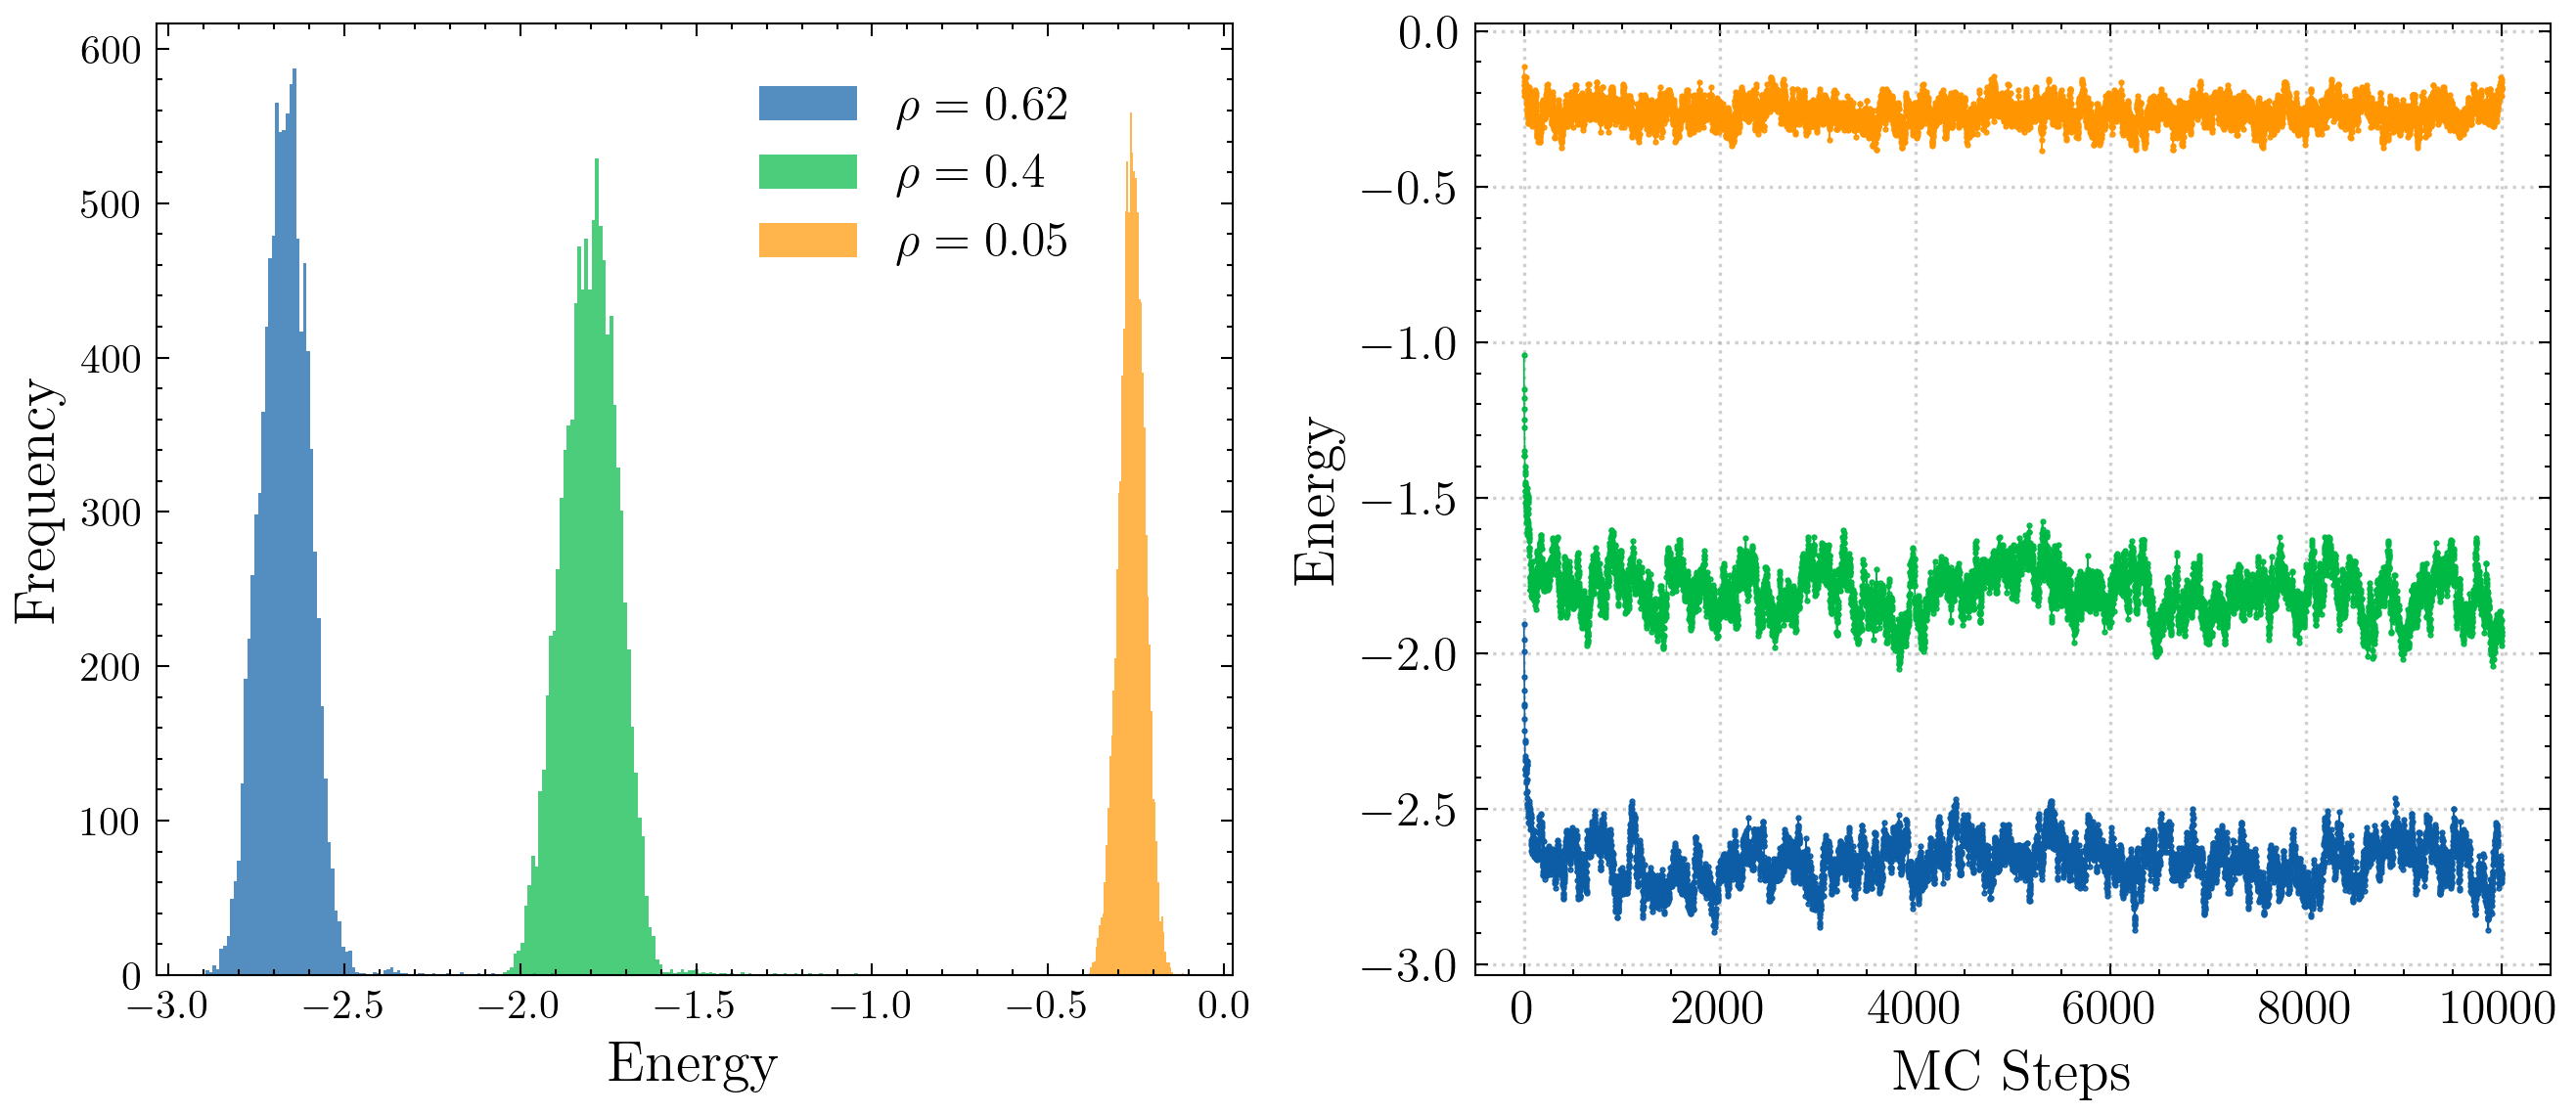

In [ ]:
# Energy analysis
data_solid = np.loadtxt('./data/energy_solid_well.dat')
data_liquid = np.loadtxt('./data/energy_liquid_well.dat')
data_gas = np.loadtxt('./data/energy_gas_well.dat')
# Create a figure with two plots: histogram and line plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4), dpi=300)

ax1.hist(data_solid[:,1], bins = 100, alpha=0.7, label=r'$\rho = 0.62$')
ax1.hist(data_liquid[:,1], bins = 100, alpha=0.7, label=r'$\rho = 0.4$')
ax1.hist(data_gas[:,1], bins = 55, alpha=0.7, label=r'$\rho = 0.05$')
ax1.set_xlabel('Energy', fontsize=14)
ax1.set_ylabel('Frequency', fontsize=14)
ax2.plot(data_solid[:,0], data_solid[:,1], marker = "o", markersize=0.5, linestyle='-', linewidth=0.4, label=r'$\rho = 0.62$')
ax2.plot(data_liquid[:,0], data_liquid[:,1], marker = "o", markersize=0.5, linestyle='-', linewidth=0.4, label=r'$\rho = 0.4$')
ax2.plot(data_gas[:,0], data_gas[:,1], marker = "o", markersize=0.5, linestyle='-', linewidth=0.4, label=r'$\rho = 0.05$')
ax2.set_xlabel('MC Steps', fontsize=14)
ax2.set_ylabel('Energy', fontsize=14)
ax2.tick_params(axis='x', labelsize=12)
ax2.tick_params(axis='y', labelsize=12)
ax2.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
# place legend at a custom position (axes fraction coordinates: x=0.95, y=0.95)
ax1.legend(framealpha=0.9, fontsize=12, loc='upper right', bbox_to_anchor=(0.89, 0.98))

#plt.savefig('./fig/Energy_analysis_well.pdf', dpi=300)
plt.tight_layout()
plt.show()

In [12]:
average_energy_solid = np.mean(data_solid[:,1])
average_energy_liquid = np.mean(data_liquid[:,1])
average_energy_gas = np.mean(data_gas[:,1])

print(f"Average Energy Solid: {average_energy_solid:.2f}")
print(f"Average Energy Liquid: {average_energy_liquid:.2f}")
print(f"Average Energy Gas: {average_energy_gas:.2f}")

Average Energy Solid: -2.67
Average Energy Liquid: -1.80
Average Energy Gas: -0.26


In [ ]:
name_file = "./data/gas.xyz"
all_frames = []
with open(name_file, 'r') as file:
    while True:
        line = file.readline()
        if not line: break  
        
        try:
            num_atoms = int(line.strip())
        except ValueError:
            break

        file.readline()

        current_frame_positions = []
        for _ in range(num_atoms):
            parts = file.readline().split()
            x, y, z = map(float, parts[1:4])
            current_frame_positions.append([x, y, z])
        
        all_frames.append(current_frame_positions)

positions = np.array(all_frames)

In [24]:
num_bonds = []
L = 15.874 

for i in range(4000, 5000):
    frame = positions[i]
    num_bond = 0
    for j in range(frame.shape[0]):
        for k in range(j + 1, frame.shape[0]):
            dr = frame[j] - frame[k]
            dr = dr - L * np.round(dr / L)
            dist = np.linalg.norm(dr)
            if dist < 1.2: 
                num_bond += 1
    num_bonds.append(num_bond)
num_bonds = np.array(num_bonds)
print("Average number of bonds in the last 1000 frames:", np.mean(num_bonds), " +/- ", np.std(num_bonds))

Average number of bonds in the last 1000 frames: 15.706  +/-  3.8459802391588025


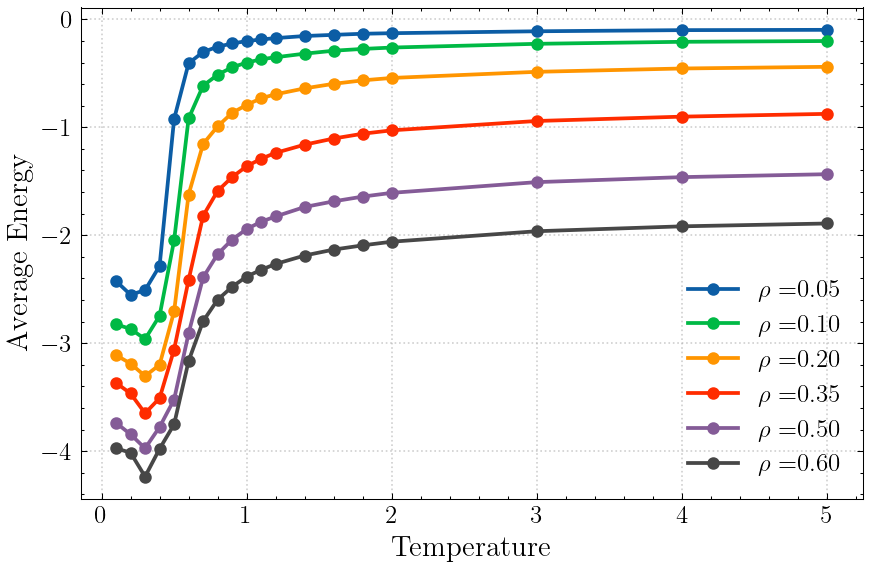

In [ ]:
temperature = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 3.0, 4.0, 5.0]
deltaTemp = np.array(temperature[1:]) - np.array(temperature[:-1])
densities = [0.05, 0.1, 0.2, 0.35, 0.5, 0.6]

plt.figure(figsize=(6, 4), dpi=150)
for d in densities:
    average_energies = []
    for t in temperature:
        data = np.loadtxt(f'./data/energy_wells/energy_T{t:.2f}_rho{d:.2f}.dat')
        average_energy = np.mean(data[:,1])
        average_energies.append(average_energy)
    #deltaEnergies = np.array(average_energies[1:]) - np.array(average_energies[:-1])
    #heat_capacity = deltaEnergies / deltaTemp
    #plt.plot(temperature[:-1],heat_capacity)
    plt.plot(temperature, average_energies, marker = "o", markersize=5, linestyle='-', linewidth=1.8, label=fr'$\rho=${d:.2f}')
    plt.xlabel('Temperature', fontsize=14)
    plt.ylabel('Average Energy', fontsize=14)
    plt.xticks(fontsize=12) 
    plt.yticks(fontsize=12)
    plt.legend(framealpha=0.9, fontsize=12)
    plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
    plt.tight_layout()
#plt.savefig('./fig/average_energy_vs_well_depth.pdf', dpi=300)
plt.show()

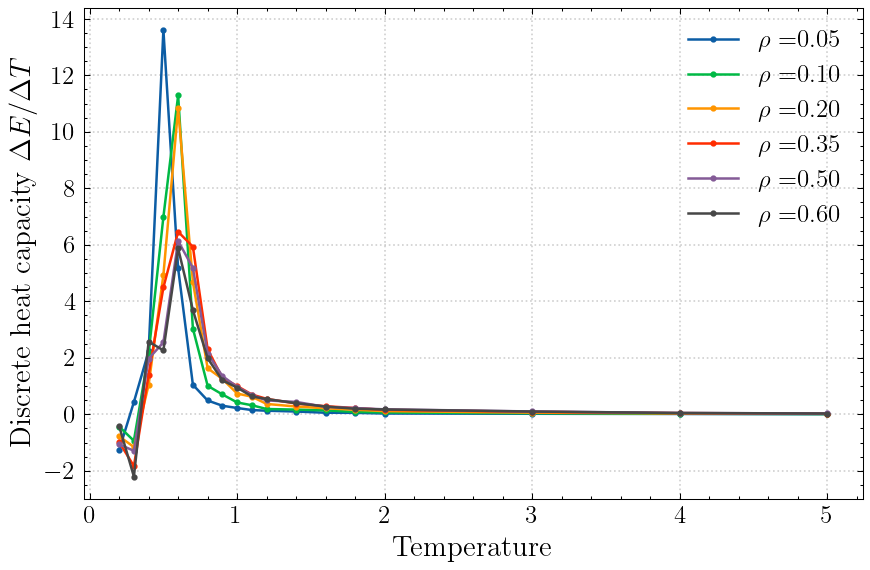

In [29]:
temperature = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0, 3.0, 4.0, 5.0]
deltaTemp = np.array(temperature[1:]) - np.array(temperature[:-1])
densities = [0.05, 0.1, 0.2, 0.35, 0.5, 0.6]

plt.figure(figsize=(6, 4), dpi=150)
for d in densities:
    average_energies = []
    for t in temperature:
        data = np.loadtxt(f'./data/energy_wells/energy_T{t:.2f}_rho{d:.2f}.dat')
        average_energy = np.mean(data[:,1])
        average_energies.append(average_energy)
    deltaEnergies = np.array(average_energies[1:]) - np.array(average_energies[:-1])
    heat_capacity = deltaEnergies / deltaTemp
    plt.plot(temperature[1:],heat_capacity,  marker = "o", markersize=2, linestyle='-', linewidth=1.2, label=fr'$\rho=${d:.2f}')
    #plt.plot(temperature, average_energies, marker = "o", markersize=5, linestyle='-', linewidth=1.8, label=fr'$\rho=${d:.2f}')
    plt.xlabel('Temperature', fontsize=14)
    plt.ylabel(rf'Discrete heat capacity $\Delta E / \Delta T$', fontsize=14)
    plt.xticks(fontsize=12) 
    plt.yticks(fontsize=12)
    plt.legend(framealpha=0.9, fontsize=12)
    plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
    plt.tight_layout()
#plt.savefig('./fig/heat_capacity_vs_well_depth.pdf', dpi=300)
plt.show()

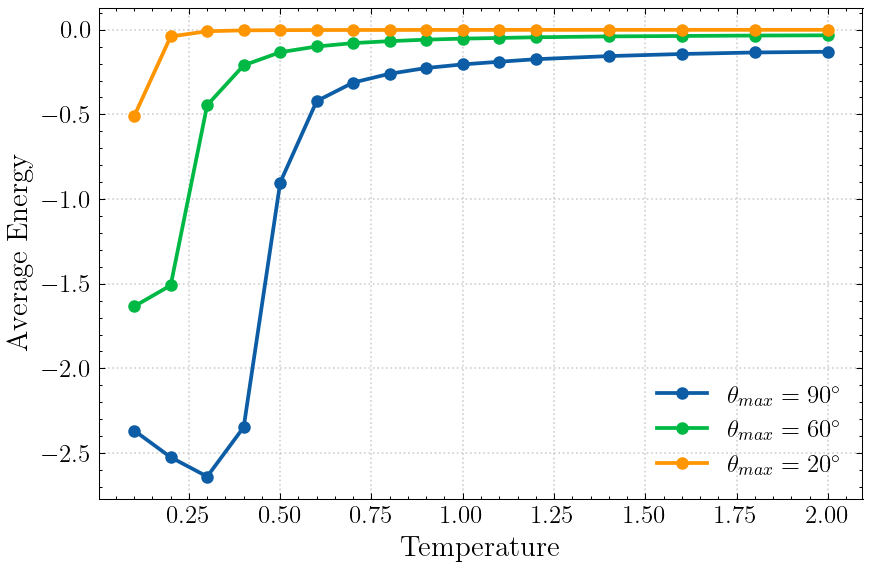

In [23]:
temperature = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 1.6, 1.8, 2.0]
deltaTemp = np.array(temperature[1:]) - np.array(temperature[:-1])
labels = [90, 60, 20]
cosThetaMax = [-0.001, 0.5, 0.93]

plt.figure(figsize=(6, 4), dpi=150)
for d in cosThetaMax:
    average_energies = []
    for t in temperature:
        data = np.loadtxt(f'./data/energy_wells/energy_T{t:.2f}_ThetaMax{d:.2f}.dat')
        average_energy = np.mean(data[:,1])
        average_energies.append(average_energy)
    #deltaEnergies = np.array(average_energies[1:]) - np.array(average_energies[:-1])
    #heat_capacity = deltaEnergies / deltaTemp
    #plt.plot(temperature[:-1],heat_capacity)
    plt.plot(temperature, average_energies, marker = "o", markersize=5, linestyle='-', linewidth=1.8, label=fr'$\theta_{{max}}={labels[cosThetaMax.index(d)]:.0f} ^\circ$')
    plt.xlabel('Temperature', fontsize=14)
    plt.ylabel('Average Energy', fontsize=14)
    plt.xticks(fontsize=12) 
    plt.yticks(fontsize=12)
    plt.legend(framealpha=0.9, fontsize=12)
    plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
    plt.tight_layout()
#plt.savefig('./fig/average_energy_vs_temp_cosThetamax.pdf', dpi=300)
plt.show()

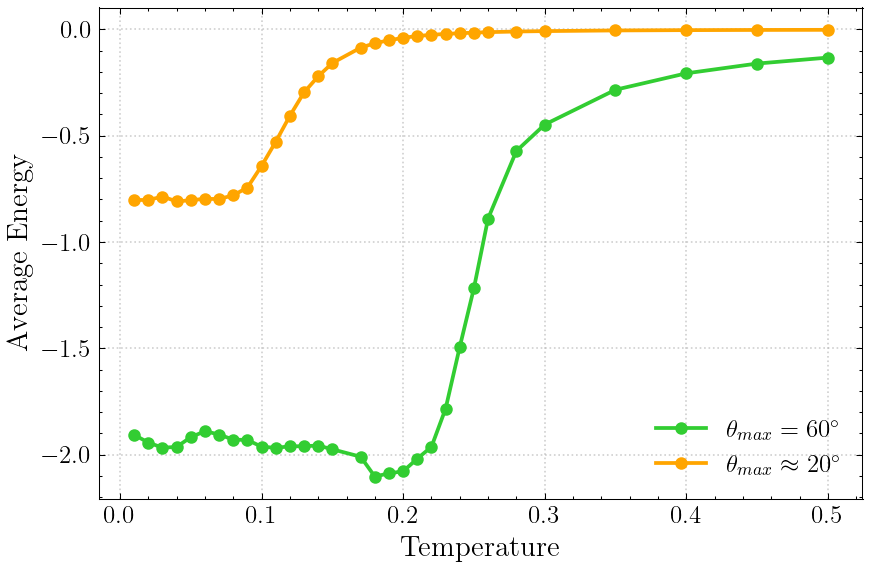

In [27]:
temperature = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15, 0.17, 0.18, 0.19, 0.20, 0.21, 0.22, 0.23, 0.24, 0.25, 0.26, 0.28, 0.30, 0.35, 0.40, 0.45, 0.5]
deltaTemp = np.array(temperature[1:]) - np.array(temperature[:-1])
cosThetaMax = [0.93]

plt.figure(figsize=(6, 4), dpi=150)
for d in cosThetaMax:
    average_energies = []
    average_energies_2 = []
    for t in temperature:
        data = np.loadtxt(f'./data/energy_wells/energy_T{t:.2f}_ThetaMax{d:.2f}.dat')
        data_2 = np.loadtxt(f'./data/energy_wells/energy_T{t:.2f}_ThetaMax0.50.dat')  # to compare
        average_energy = np.mean(data[:,1])
        average_energies.append(average_energy)
        average_energy_2 = np.mean(data_2[:,1])
        average_energies_2.append(average_energy_2)
    #deltaEnergies = np.array(average_energies[1:]) - np.array(average_energies[:-1])
    #heat_capacity = deltaEnergies / deltaTemp
    #plt.plot(temperature[:-1],heat_capacity)

    plt.plot(temperature, average_energies_2,color = "limegreen", marker = "o", markersize=5, linestyle='-', linewidth=1.8, label=fr'$\theta_{{max}}=60^\circ$')
    plt.plot(temperature, average_energies,color="orange", marker = "o", markersize=5, linestyle='-', linewidth=1.8, label=fr'$\theta_{{max}}\approx 20^\circ$')
    plt.xlabel('Temperature', fontsize=14)
    plt.ylabel('Average Energy', fontsize=14)
    plt.xticks(fontsize=12) 
    plt.yticks(fontsize=12)
    plt.legend(framealpha=0.9, fontsize=12)
    plt.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)
    plt.tight_layout()
plt.savefig('./fig/average_energy_vs_temp_cosThetamax_zoom.pdf', dpi=300)
plt.show()

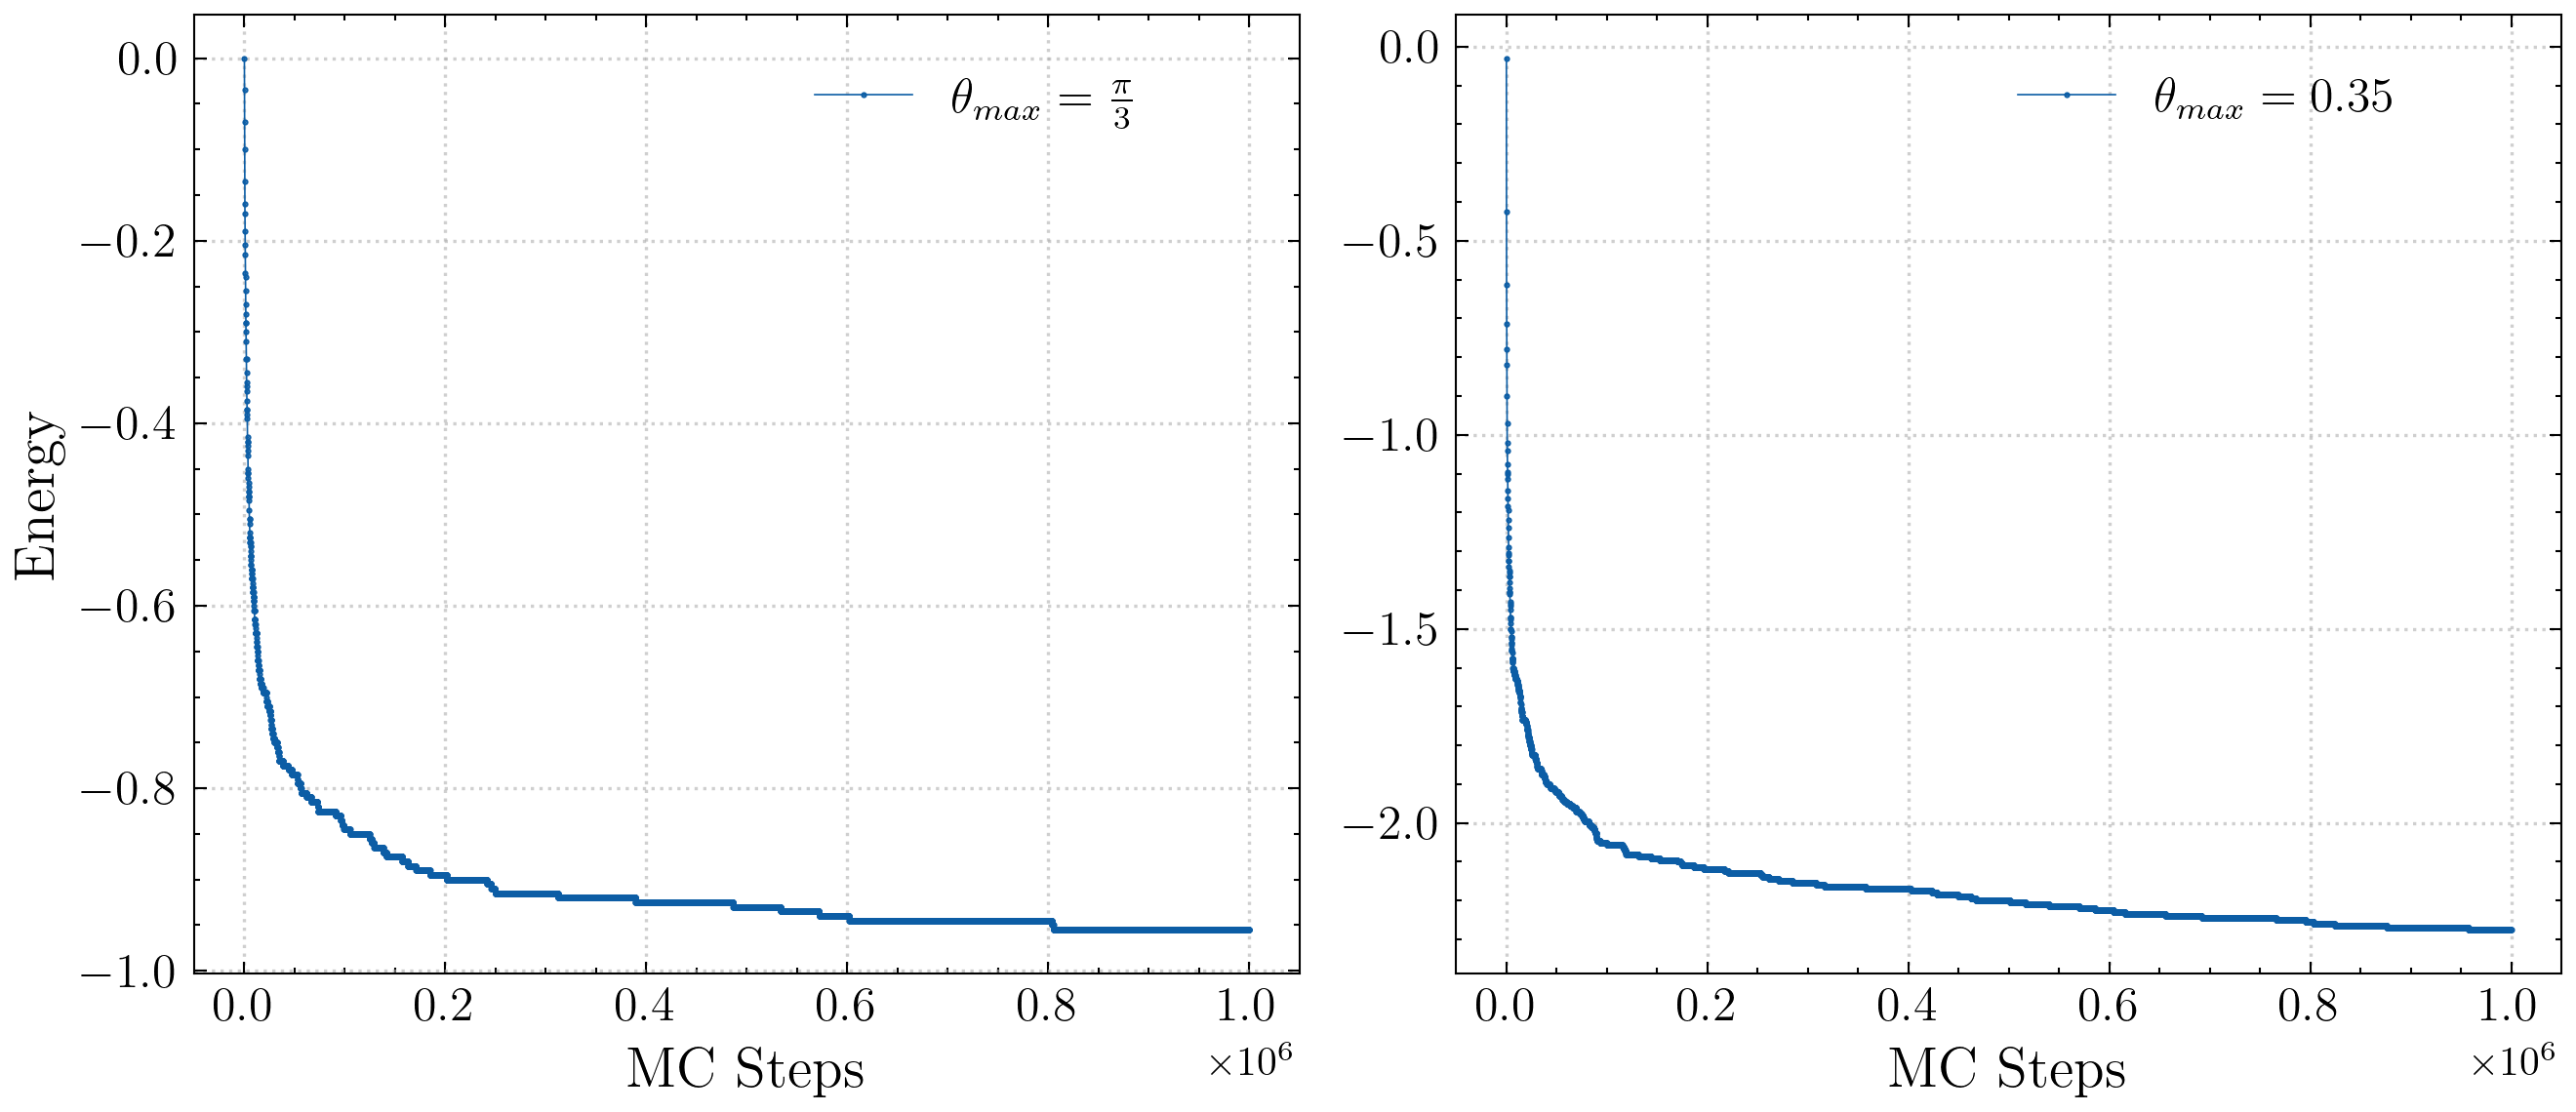

-0.9549999999999998 1.1102230246251565e-16
-2.2721259499999995 0.002471858935598822


In [ ]:
# Energy analysis
data = np.loadtxt('./data/energy_linear_narrow.dat')
data2 = np.loadtxt('./data/energy_linear_broad.dat')

fig, (ax, ax1) = plt.subplots(1,2,figsize=(9, 4), dpi=300)
ax.plot(data[::100,0], data[::100,1], marker = "o", markersize=0.5, linestyle='-', linewidth=0.4, label=r'$\theta_{max} = \frac{\pi}{3}$')
ax.set_xlabel('MC Steps', fontsize=14)
ax.set_ylabel('Energy', fontsize=14)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(framealpha=0.9, fontsize=12, loc='upper right', bbox_to_anchor=(0.89, 0.98))
ax.grid(True, linestyle=':', linewidth=0.8, alpha=0.6)

ax1.plot(data2[::100,0], data2[::100,1], marker = "o", markersize=0.5, linestyle='-', linewidth=0.4, label=r'$\theta_{max} = 0.35$')
ax1.set_xlabel('MC Steps', fontsize=14)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.legend(framealpha=0.9, fontsize=12, loc='upper right', bbox_to_anchor=(0.89, 0.98))
ax1.grid(True, linestyle=':', linewidth=0.8, alpha=0.6  )   

#plt.savefig('./fig/Energy_trace_plots_patch.pdf', dpi=100)
plt.tight_layout()
plt.show()

print(np.mean(data[900000:,1]), np.std(data[900000:,1]))
print(np.mean(data2[900000:,1]), np.std(data2[900000:,1]))